Let's have a look at the [used cars dataset](https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data) from Kaggle.

In [2]:
import pandas as pd
df = pd.read_csv('vehicles.csv.gz')
df

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600


Following information is recorded for the advertisements:

In [5]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

Let's pick the top 5 manufacturers and produce a bar plot of the counts of advertisements.

In [8]:
top_manufacturers = df['manufacturer'].value_counts().iloc[:5]
top_manufacturers

manufacturer
ford         70985
chevrolet    55064
toyota       34202
honda        21269
nissan       19067
Name: count, dtype: int64

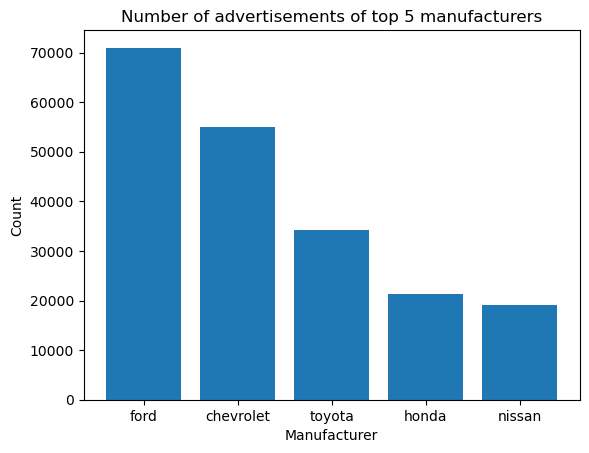

In [10]:
import matplotlib.pyplot as plt
import numpy as np
top_manufacturers = df['manufacturer'].value_counts().iloc[:5]
plt.bar(np.arange(len(top_manufacturers)),top_manufacturers,tick_label=top_manufacturers.index.tolist())
plt.xlabel('Manufacturer')
plt.ylabel('Count')
plt.title('Number of advertisements of top 5 manufacturers')
plt.savefig('barplot_top_5_manufacturers.pdf')

What about the number of advertisements by the fuel? We can produce a barplot where we have multiple bars by the fuel for each manufacturer.

In [13]:
df['fuel'].dropna().unique()

array(['gas', 'other', 'diesel', 'hybrid', 'electric'], dtype=object)

Let's choose the values manually so that they make sense.

In [16]:
fuels = ['gas','diesel','hybrid','electric']

In [18]:
manufacturer_and_fuel = df.query('manufacturer in @top_manufacturers.index and fuel in @fuels') \
    [['manufacturer','fuel']]
manufacturer_and_fuel

,manufacturer,fuel
28,chevrolet,gas
29,chevrolet,gas
30,toyota,gas
31,ford,gas
33,chevrolet,gas
...,...,...
426856,nissan,gas
426857,toyota,gas
426864,toyota,gas
426868,toyota,gas


We want to get the count of each fuel value by manufacturer, so we use `groupby` and `value_counts`.

In [21]:
manufacturer_fuel_counts = manufacturer_and_fuel.groupby('manufacturer').value_counts()
manufacturer_fuel_counts

manufacturer  fuel    
chevrolet     gas         46386
              diesel       3614
              hybrid        244
              electric      185
ford          gas         54669
              diesel      10282
              hybrid        693
              electric       77
honda         gas         19996
              hybrid        326
              diesel         33
              electric       25
nissan        gas         17736
              electric      256
              diesel        166
              hybrid         41
toyota        gas         29168
              hybrid       2248
              diesel        160
              electric       40
Name: count, dtype: int64

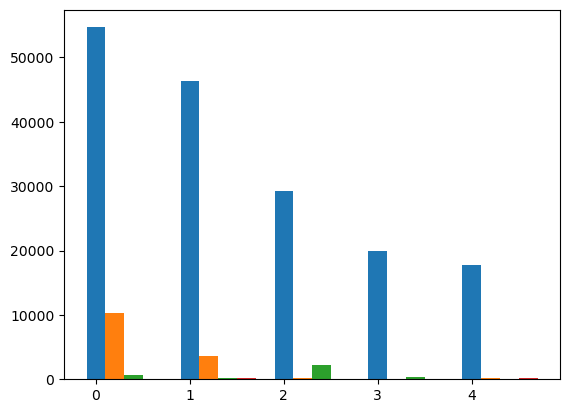

In [23]:
width = 1.0/(len(fuels)+1)
for (i,fuel) in enumerate(fuels):
    xs = np.arange(len(top_manufacturers)) + i*width
    ys = [manufacturer_fuel_counts[manufacturer][fuel] for manufacturer in top_manufacturers.index]
    plt.bar(xs,ys,width=width)

The number of petrol-powered cars is so huge that we can hardly see anything on the other axes. What if we used a logarithmic scale instead?

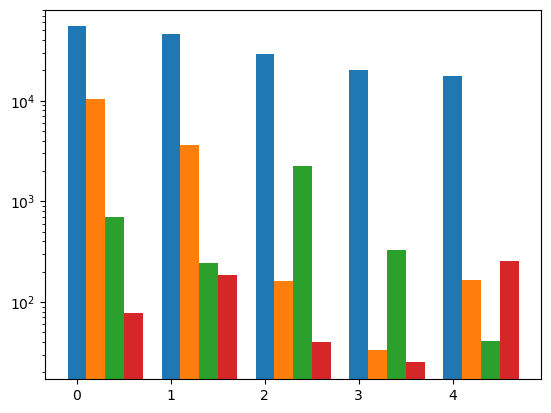

In [26]:
width = 1.0/(len(fuels)+1)
for (i,fuel) in enumerate(fuels):
    xs = np.arange(len(top_manufacturers)) + i*width
    ys = [manufacturer_fuel_counts[manufacturer][fuel] for manufacturer in top_manufacturers.index]
    plt.bar(xs,ys,width=width)
plt.yscale('log')

But we still need a legend and proper tick labels to make sense (and readers should be warned about the logarithmic scale).

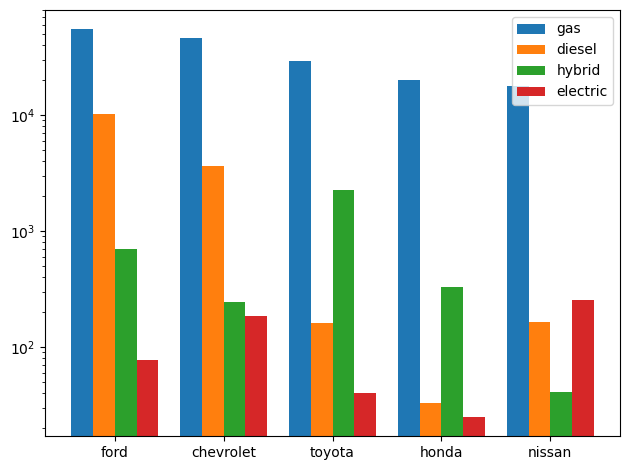

In [29]:
width = 1.0/(len(fuels)+1)
for (i,fuel) in enumerate(fuels):
    xs = np.arange(len(top_manufacturers)) + i*width
    ys = [manufacturer_fuel_counts[manufacturer][fuel] for manufacturer in top_manufacturers.index]
    plt.bar(xs,ys,width=width,label=fuel)
plt.xticks(np.arange(len(top_manufacturers))+1.5*width,top_manufacturers.index.tolist())
plt.yscale('log')
plt.legend()
plt.tight_layout()

The legend looks ugly when it comes on top of the bars. We can fix this with the following trick. We will also create a custom figure so that we can adjust it to be slightly wider.

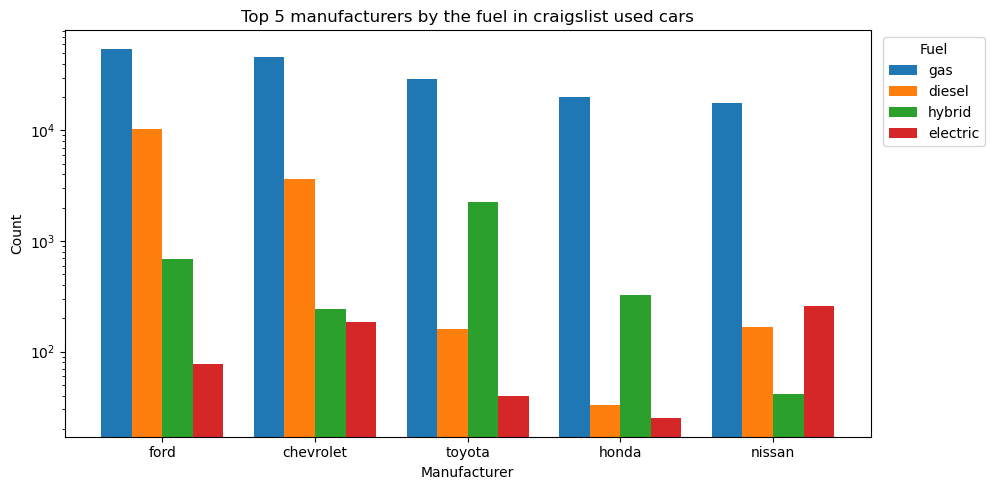

In [32]:
fig, ax = plt.subplots(figsize=(10,5))
width = 1.0/(len(fuels)+1)
for (i,fuel) in enumerate(fuels):
    xs = np.arange(len(top_manufacturers)) + i*width
    ys = [manufacturer_fuel_counts[manufacturer][fuel] for manufacturer in top_manufacturers.index]
    ax.bar(xs,ys,width=width,label=fuel)
ax.set_xticks(np.arange(len(top_manufacturers))+1.5*width,top_manufacturers.index.tolist())
ax.set_yscale('log')
ax.legend(bbox_to_anchor=(1.15, 1),title='Fuel')
plt.xlabel('Manufacturer')
plt.ylabel('Count')
plt.title('Top 5 manufacturers by the fuel in craigslist used cars')
fig.tight_layout()
plt.savefig('barplot_top_5_manufacturers_by_fuel.pdf')

Let's find out the most common model from the most common manufacturer.

In [35]:
df['manufacturer'].value_counts()

manufacturer
ford               70985
chevrolet          55064
toyota             34202
honda              21269
nissan             19067
jeep               19014
ram                18342
gmc                16785
bmw                14699
dodge              13707
mercedes-benz      11817
hyundai            10338
subaru              9495
volkswagen          9345
kia                 8457
lexus               8200
audi                7573
cadillac            6953
chrysler            6031
acura               5978
buick               5501
mazda               5427
infiniti            4802
lincoln             4220
volvo               3374
mitsubishi          3292
mini                2376
pontiac             2288
rover               2113
jaguar              1946
porsche             1384
mercury             1184
saturn              1090
alfa-romeo           897
tesla                868
fiat                 792
harley-davidson      153
ferrari               95
datsun                63
aston-martin

In [37]:
df.query('manufacturer == "ford"')['model'].value_counts()

model
f-150                                        8009
escape                                       2745
explorer                                     2499
mustang                                      2220
fusion                                       1979
                                             ... 
f-150 crew cab limited                          1
f-550 service truck under deck compressor       1
runabout roadster                               1
f150 fx-2 sport                                 1
f150, platinum                                  1
Name: count, Length: 3874, dtype: int64

So this turns out to be the Ford F-150. Let's choose these and keep only the (potentially) interesting columns.

In [40]:
f150 = df.query('manufacturer == "ford" and model == "f-150"') \
    [['price','year','fuel','odometer','transmission']].dropna()
f150

,price,year,fuel,odometer,transmission
228,5500,1978.0,gas,239000.0,automatic
235,27995,2017.0,gas,101000.0,automatic
249,37500,2018.0,gas,30026.0,automatic
337,8950,2011.0,gas,164000.0,automatic
537,3500,2006.0,gas,246000.0,automatic
...,...,...,...,...,...
426444,9000,2011.0,gas,165000.0,automatic
426456,9500,1979.0,gas,68000.0,automatic
426613,26500,2015.0,gas,61367.0,automatic
426664,950,1995.0,gas,209452.0,automatic


What does the distribution of year-models look like?

In [43]:
f150['year'].describe()

count    7814.000000
mean     2012.337599
std         6.502581
min      1932.000000
25%      2010.000000
50%      2014.000000
75%      2017.000000
max      2022.000000
Name: year, dtype: float64

The data is somehow off because the F-150 was introduced in 1948. However, let's look at the more recent years (which should be plentiful).

In [46]:
np.sum(f150['year'] >= 2000),np.sum(f150['year'] < 2000)

(7498, 316)

In [48]:
f150 = df.query('manufacturer == "ford" and model == "f-150" and year >= 2000') \
    [['price','year','fuel','odometer','transmission']].dropna()

Let's plot a histogram of the years.

(array([ 244.,  315.,  350.,  326.,  586., 1569., 1353., 1291., 1205.,
         259.]),
 array([2000. , 2002.2, 2004.4, 2006.6, 2008.8, 2011. , 2013.2, 2015.4,
        2017.6, 2019.8, 2022. ]),
 <BarContainer object of 10 artists>)

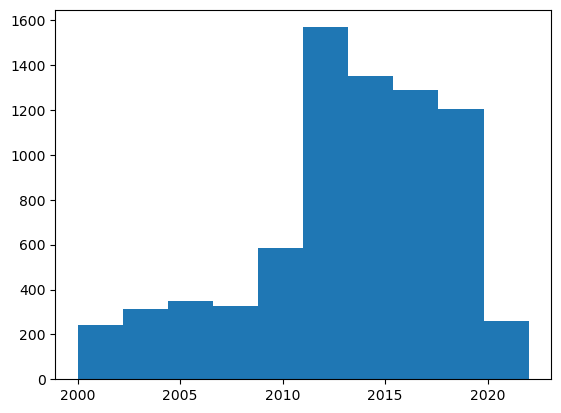

In [51]:
plt.hist(f150['year'])

There's probably too few bins here to understand the structure. Let's increase that. `auto` is often a good guess.

(array([ 55.,  86.,   0., 103., 162.,   0., 153.,   0., 131., 219.,   0.,
        178.,   0., 148., 141.,   0., 445.,   0., 339., 395.,   0., 835.,
        752.,   0., 601.,   0., 622., 669.,   0., 851.,   0., 354., 232.,
          0.,  26.,   1.]),
 array([2000.        , 2000.61111111, 2001.22222222, 2001.83333333,
        2002.44444444, 2003.05555556, 2003.66666667, 2004.27777778,
        2004.88888889, 2005.5       , 2006.11111111, 2006.72222222,
        2007.33333333, 2007.94444444, 2008.55555556, 2009.16666667,
        2009.77777778, 2010.38888889, 2011.        , 2011.61111111,
        2012.22222222, 2012.83333333, 2013.44444444, 2014.05555556,
        2014.66666667, 2015.27777778, 2015.88888889, 2016.5       ,
        2017.11111111, 2017.72222222, 2018.33333333, 2018.94444444,
        2019.55555556, 2020.16666667, 2020.77777778, 2021.38888889,
        2022.        ]),
 <BarContainer object of 36 artists>)

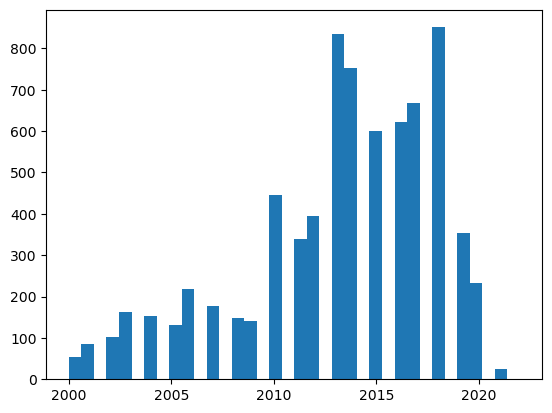

In [54]:
plt.hist(f150['year'],bins='auto')

But now we get empty bins because the years are discrete and we get no entries, e.g., in the interval between 2001.22222222 and 2001.83333333. So let's take the number of years as such.

(array([ 55.,  86., 103., 162., 153., 131., 219., 178., 148., 141., 445.,
        339., 395., 835., 752., 601., 622., 669., 851., 354., 232.,  26.,
          1.]),
 array([2000.        , 2000.95652174, 2001.91304348, 2002.86956522,
        2003.82608696, 2004.7826087 , 2005.73913043, 2006.69565217,
        2007.65217391, 2008.60869565, 2009.56521739, 2010.52173913,
        2011.47826087, 2012.43478261, 2013.39130435, 2014.34782609,
        2015.30434783, 2016.26086957, 2017.2173913 , 2018.17391304,
        2019.13043478, 2020.08695652, 2021.04347826, 2022.        ]),
 <BarContainer object of 23 artists>)

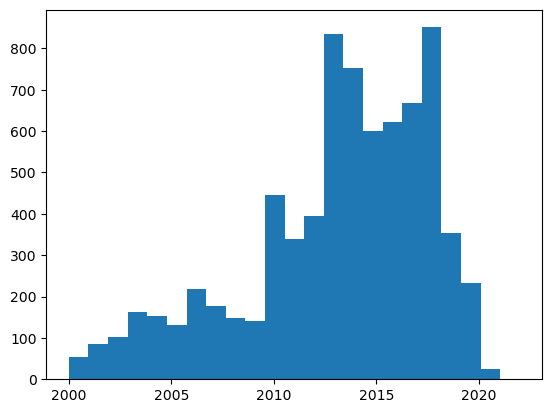

In [57]:
plt.hist(f150['year'],bins=int(f150['year'].max() - f150['year'].min()+1))

Let's wrap this up with appropriate labels and titles.

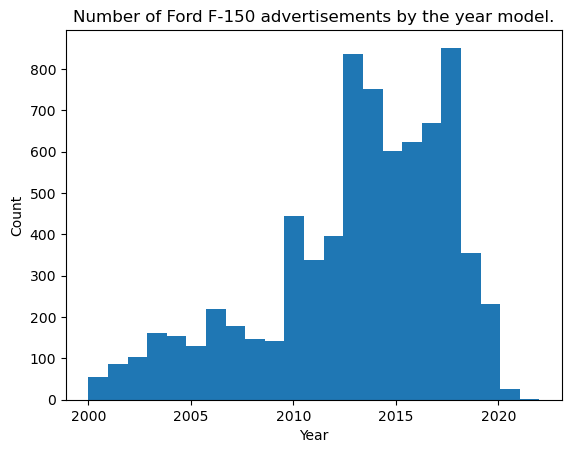

In [60]:
plt.hist(f150['year'],bins=int(f150['year'].max() - f150['year'].min()+1))
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Number of Ford F-150 advertisements by the year model.')
plt.savefig('f150_histogram.pdf')

Let's look at Toyotas. We'll restrict ourselves to petrol and hybrids only.

In [63]:
toyota_gas_hybrid = df.query('manufacturer == "toyota" and fuel in ["gas","hybrid"]')

Is there a relationship between the odometer figure and price?

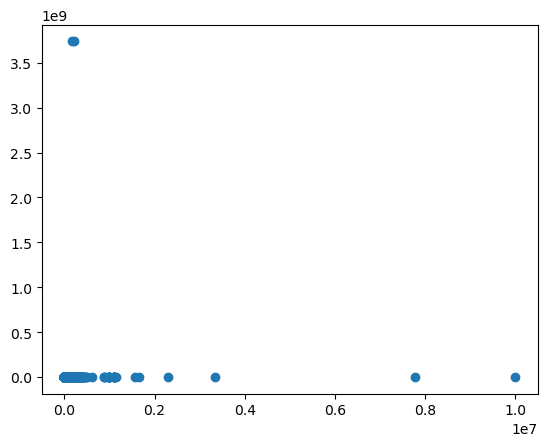

In [66]:
plt.scatter(toyota_gas_hybrid['odometer'],toyota_gas_hybrid['price'])

We can't see anything because there's an outlier. What is it?

In [69]:
toyota_gas_hybrid.query('price > 1e9')

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
318592,7308056031,https://eugene.craigslist.org/cto/d/florence-2...,eugene,https://eugene.craigslist.org,3736928711,2007.0,toyota,tundra,excellent,8 cylinders,...,full-size,pickup,silver,https://images.craigslist.org/00v0v_3K0RsmdR5c...,Selling my 2007 Toyota Tundra SR5 four wheel d...,NaN,or,44.066092,-124.037561,2021-04-16T18:16:12-0700
356716,7302445002,https://knoxville.craigslist.org/cto/d/new-mar...,knoxville,https://knoxville.craigslist.org,3736928711,1999.0,toyota,4runner,fair,6 cylinders,...,mid-size,NaN,green,https://images.craigslist.org/00Y0Y_f6XKAW6imi...,"99 four runner 211,000 miles runs great 4x4 wo...",NaN,tn,36.081000,-83.567300,2021-04-05T23:15:48-0400


In [71]:
toyota_gas_hybrid.query('odometer > 8e6')['odometer']

67003    10000000.0
Name: odometer, dtype: float64

These entries are obviously bogus because no car can be priced at above 1 billion dollars (or it's somehow a very weird car). So let's remove that. And let's do the same with some weird odometer values. It's highly likely that a car can have an odometer rating of *exactly* 10 million miles.

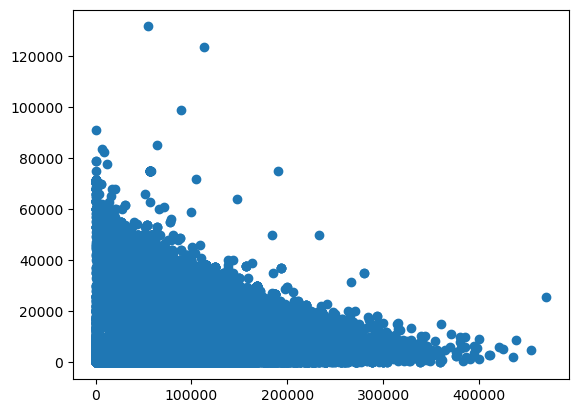

In [74]:
toyota_gas_hybrid = df.query('manufacturer == "toyota" and fuel in ["gas","hybrid"] and price < 1e6 and odometer < 0.5e6')[['fuel','price','odometer']].dropna()
plt.scatter(toyota_gas_hybrid['odometer'],toyota_gas_hybrid['price'])

There *might* be some kind of relationship. Let's explore this further. What happens if we make the markers smaller?

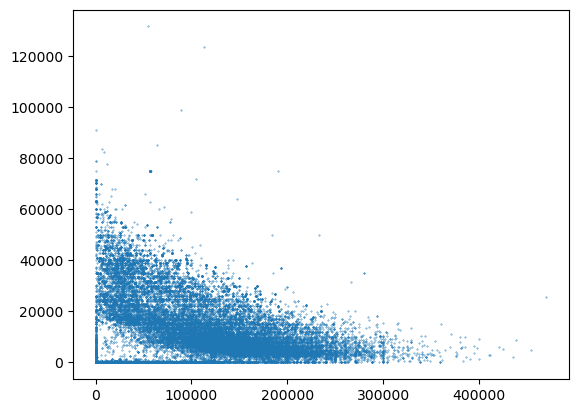

In [77]:
plt.scatter(toyota_gas_hybrid['odometer'],toyota_gas_hybrid['price'],s=0.1)

It looks like there are also bogus values around zero, so let's get rid of those as well. 

Text(0.5, 1.0, 'Toyota advertisements price vs. odometer reading')

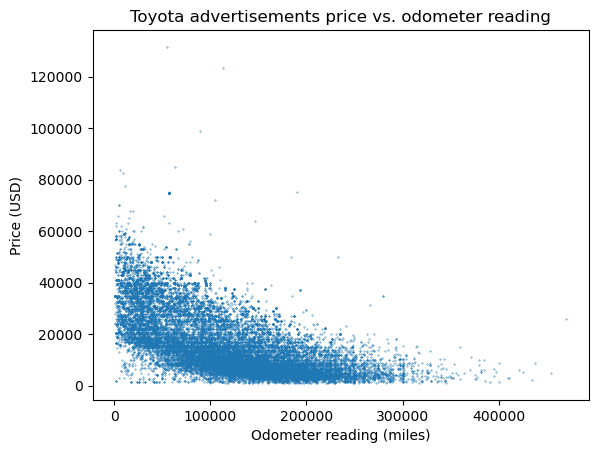

In [80]:
toyota_gas_hybrid = df.query('manufacturer == "toyota" and fuel in ["gas","hybrid"] and ' + \
                             '1e3 < price < 1e6 and 1e3 < odometer < 0.5e6')[['fuel','price','odometer']].dropna()
plt.scatter(toyota_gas_hybrid['odometer'],toyota_gas_hybrid['price'],s=0.1)
plt.xlabel('Odometer reading (miles)')
plt.ylabel('Price (USD)')
plt.title('Toyota advertisements price vs. odometer reading')

Now it's starting to look like there is a relationship. Let's explore this further with a 2-dimensional histogram.

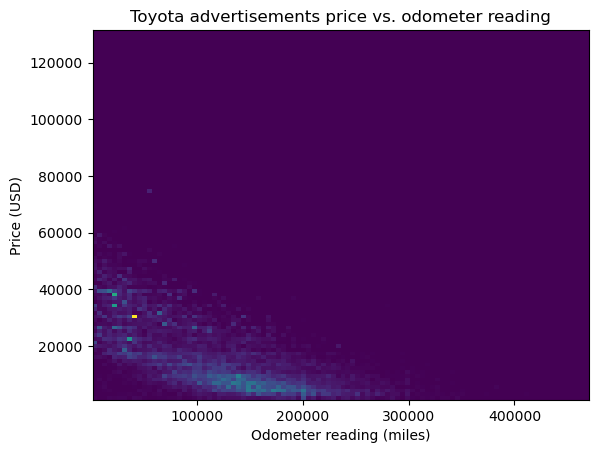

In [83]:
toyota_gas_hybrid = df.query('manufacturer == "toyota" and fuel in ["gas","hybrid"] and ' + \
                             '1e3 < price < 1e6 and 1e3 < odometer < 0.5e6')[['fuel','price','odometer']].dropna()
plt.hist2d(toyota_gas_hybrid['odometer'],toyota_gas_hybrid['price'],bins=100)
plt.xlabel('Odometer reading (miles)')
plt.ylabel('Price (USD)')
plt.title('Toyota advertisements price vs. odometer reading')
plt.savefig('hist2d_toyota_gas_hybrid_odometer_vs_price.pdf')

Does fuel have impact? Let's make another scatter plot, but colorize the dots by the fuel.

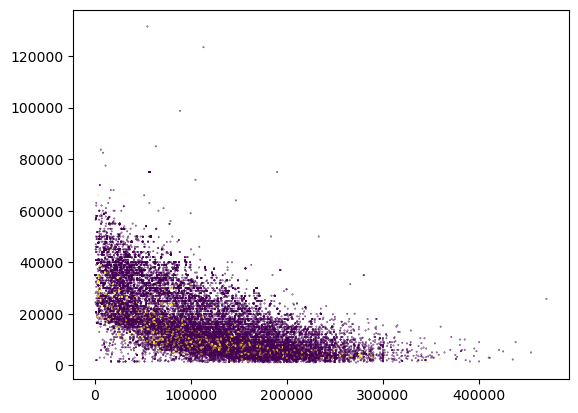

In [86]:
plt.scatter(toyota_gas_hybrid['odometer'],toyota_gas_hybrid['price'],s=0.1,
    c = toyota_gas_hybrid['fuel'].map({'gas' : 0, 'hybrid' : 1}))

If there is a relationship, it's not clear; this is probably explained by the fact that we have different models spread amongst one another. How about model year?

Text(0.5, 1.0, 'Toyota odometer reading vs. prices by the model year')

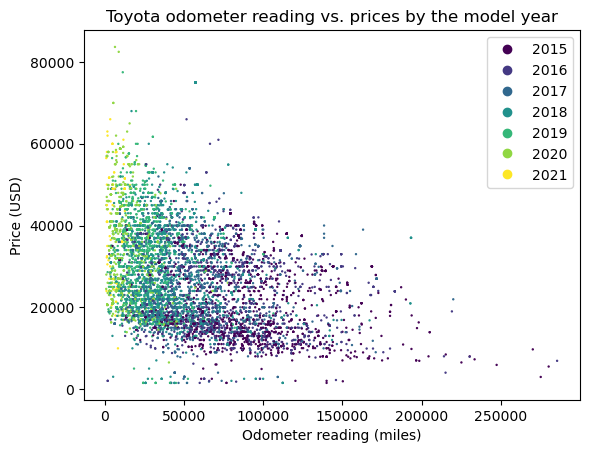

In [89]:
toyota_gas_hybrid = df.query('manufacturer == "toyota" and fuel in ["gas","hybrid"] and ' + \
                             '1e3 < price < 1e6 and 1e3 < odometer < 3e5 and ' + \
                             '2015 <= year <= 2021')
years = list(sorted(toyota_gas_hybrid['year'].unique()))
year_to_class_map = { y : i for (i,y) in enumerate(years) }
scatter = plt.scatter(toyota_gas_hybrid['odometer'],
                      toyota_gas_hybrid['price'],
                      c=toyota_gas_hybrid['year'].map(year_to_class_map),
                      s=0.5, cmap='viridis')
plt.legend(handles=scatter.legend_elements()[0], labels=list(map(int,years)))
plt.xlabel('Odometer reading (miles)')
plt.ylabel('Price (USD)')
plt.title('Toyota odometer reading vs. prices by the model year')

Viridis is a perceptually uniform sequential colormap, so it helps seeing the effect the sequential values (years in this case) have. It turns out (perhaps unsurprisingly) that it's not just the odometer reading but the age of the car that determine its value.

We can get a better idea if we restrifct ourselves to only the most common Toyota model.

In [93]:
toyota_gas_hybrid['model'].value_counts()

model
tacoma                   951
camry                    707
corolla                  660
rav4                     500
tundra                   345
                        ... 
pilot exl                  1
tacoma 4wd sr5             1
rav4 limited 4wd           1
4runner trd pro - suv      1
rav4 le automatic          1
Name: count, Length: 609, dtype: int64

Tacoma is the most common model. 

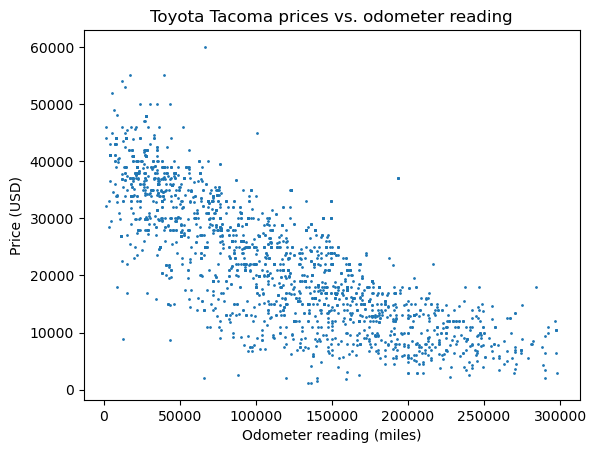

In [96]:
tacoma = df.query('manufacturer == "toyota" and model == "tacoma" and ' + \
                  '1000 < price < 1e5 and 1000 < odometer < 3e5 ')[['year','odometer','price']]
plt.scatter(tacoma['odometer'],tacoma['price'],s=1)
plt.xlabel('Odometer reading (miles)')
plt.ylabel('Price (USD)')
plt.title('Toyota Tacoma prices vs. odometer reading')
plt.savefig('tacoma_price_vs_odometer.pdf')

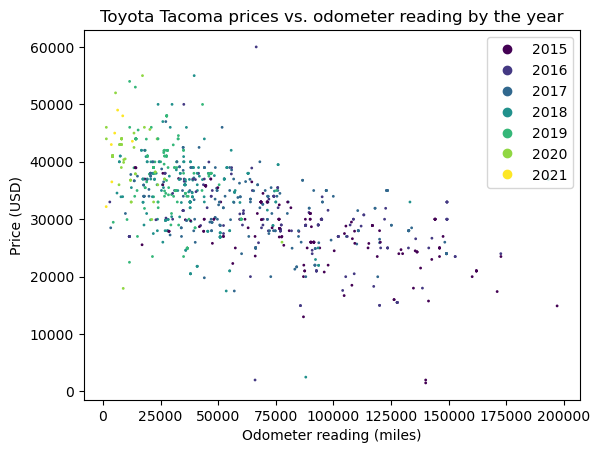

In [98]:
tacoma = df.query('manufacturer == "toyota" and model == "tacoma" and ' + \
                  '1000 < price < 1e5 and 1000 < odometer < 3e5 and ' + \
                  '2015 <= year <= 2021')[['year','odometer','price']]
years = list(sorted(tacoma['year'].unique()))
year_to_class_map = { y : i for (i,y) in enumerate(years) }
scatter = plt.scatter(tacoma['odometer'],tacoma['price'],s=1,
                     c = tacoma['year'].map(year_to_class_map),
                     cmap = 'viridis')
plt.legend(handles=scatter.legend_elements()[0], labels=list(map(int,years)),loc=1)
plt.xlabel('Odometer reading (miles)')
plt.ylabel('Price (USD)')
plt.title('Toyota Tacoma prices vs. odometer reading by the year')
plt.savefig('tacoma_price_vs_odometer_by_year.pdf')

Let's finally plot a boxplot of the prices in different years.

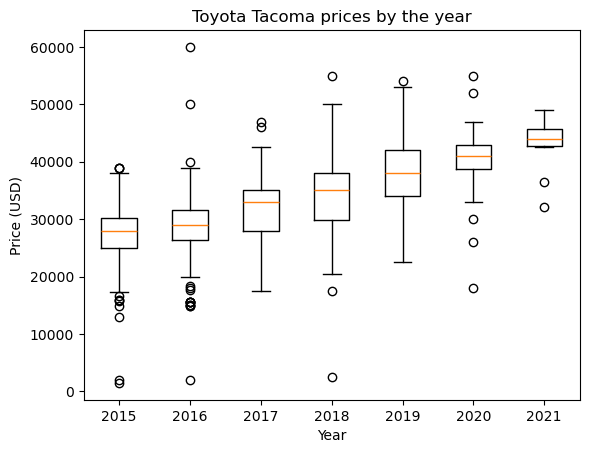

In [103]:
tacoma = df.query('manufacturer == "toyota" and model == "tacoma" and ' + \
                  '2015 <= year <= 2021 and ' \
                  'price > 1e3')[['year','price']]
years = list(sorted(tacoma['year'].unique().astype(int)))
prices_by_year = [ tacoma.query('year == @year')['price'] for year in years ]
plt.boxplot(prices_by_year,tick_labels=years)
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.title('Toyota Tacoma prices by the year')
plt.savefig('boxplot_tacoma_prices_by_year.pdf')

The components of the boxplot (or box and whiskers plot) are as follows:
- The box shows the range between first and third quartile (Q1 and Q3)
- Median is the horizontal line within the box
- Whiskers extend to at most 1.5 IQR (inter-quartile range), that is, 1.5*(Q3-Q1), the range of values around the median where we would typically expect to see most values; whiskers always end up in a datapoint
- Points outside this range are *outliers* and they are represented as circles in this plot

Seaborn is very convenient for creating barplots.

Text(0.5, 1.0, 'Advertisement count by the manufacturer')

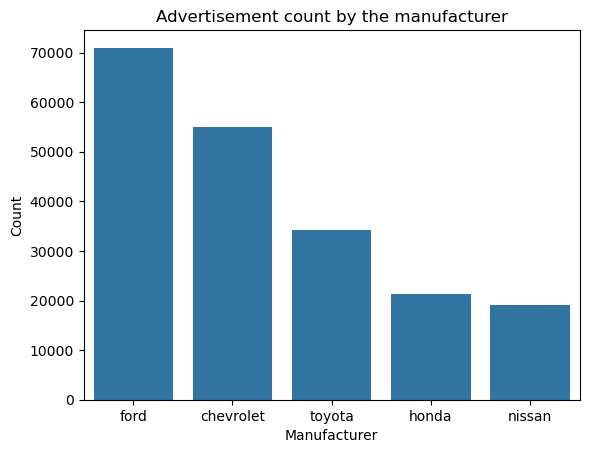

In [107]:
import seaborn as sns
g = sns.barplot(data=df['manufacturer'].value_counts().iloc[:5].reset_index(),x='manufacturer',y='count')
g.set_xlabel('Manufacturer')
g.set_ylabel('Count')
g.set_title('Advertisement count by the manufacturer')

The `hue` is particularly useful here.

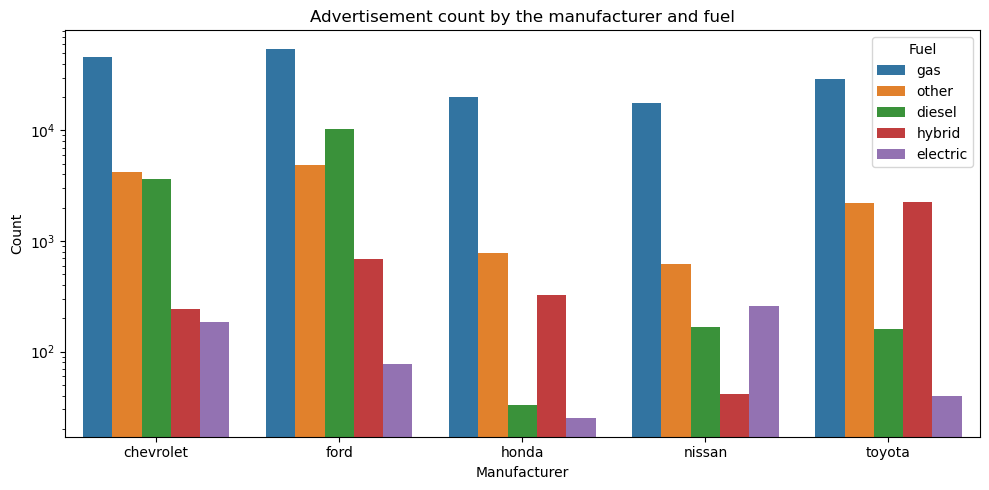

In [110]:
top_manufacturers = df['manufacturer'].value_counts().iloc[:5].index.tolist()
df2 = df.query('manufacturer in @top_manufacturers').groupby('manufacturer')['fuel'].value_counts().reset_index()
plt.figure(figsize=(10,5))
g = sns.barplot(data=df2,x='manufacturer',y='count',hue='fuel')
g.set_xlabel('Manufacturer')
g.set_ylabel('Count')
g.set_title('Advertisement count by the manufacturer and fuel')
g.set_yscale('log')
legend_handles, legend_labels = g.get_legend_handles_labels()
g.legend(legend_handles, legend_labels, title = 'Fuel')
plt.tight_layout()

A histogram can be plotted with `histplot`. We need not decide the number of bins, but we can also choose the width of the bin instead.

Text(0.5, 1.0, 'Number of Ford F-150 announcements by the model year')

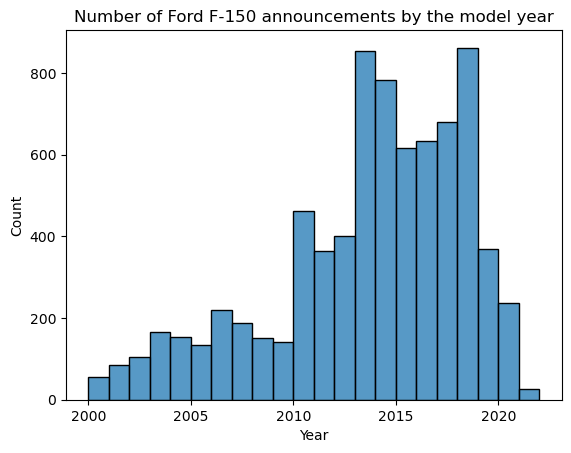

In [113]:
df2 = df.query('year >= 2000 and manufacturer == "ford" and model == "f-150"')
g = sns.histplot(data=df2,x='year',binwidth=1)
g.set_xlabel('Year')
g.set_ylabel('Count')
g.set_title('Number of Ford F-150 announcements by the model year')

Scatter plots are also easy.

Text(0.5, 1.0, 'Toyota prices vs. odometer reading by the fuel')

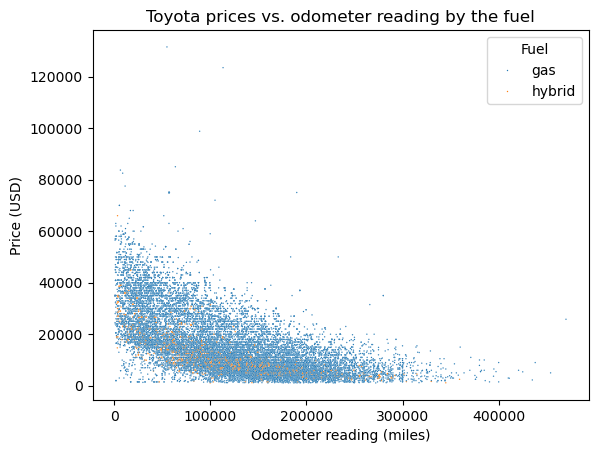

In [116]:
toyota_gas_hybrid = df.query('manufacturer == "toyota" and fuel in ["gas","hybrid"] and ' + \
                             '1e3 < price < 1e6 and 1e3 < odometer < 0.5e6')[['fuel','price','odometer']].dropna()
g = sns.scatterplot(data=toyota_gas_hybrid,x='odometer',y='price',hue='fuel',s=1)
legend_handles, legend_labels = g.get_legend_handles_labels()
g.legend(legend_handles, legend_labels, title = 'Fuel')
g.set_xlabel('Odometer reading (miles)')
g.set_ylabel('Price (USD)')
g.set_title('Toyota prices vs. odometer reading by the fuel')

Then a 2d histogram.

Text(0.5, 1.0, 'Toyota prices vs. odometer')

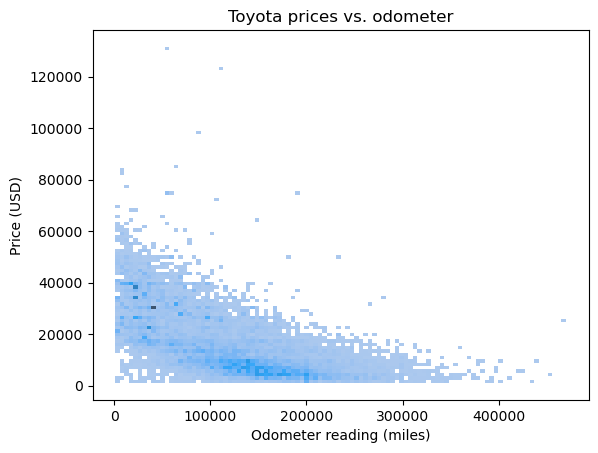

In [119]:
toyota_gas_hybrid = df.query('manufacturer == "toyota" and fuel in ["gas","hybrid"] and ' + \
                             '1e3 < price < 1e6 and 1e3 < odometer < 0.5e6')[['fuel','price','odometer']].dropna()
g = sns.histplot(data=toyota_gas_hybrid,x='odometer',y='price',bins=100)
g.set_xlabel('Odometer reading (miles)')
g.set_ylabel('Price (USD)')
g.set_title('Toyota prices vs. odometer')

Finally, a scatterplot with hue by the year.

Text(0.5, 1.0, 'Toyota prices vs. odometer reading by the year')

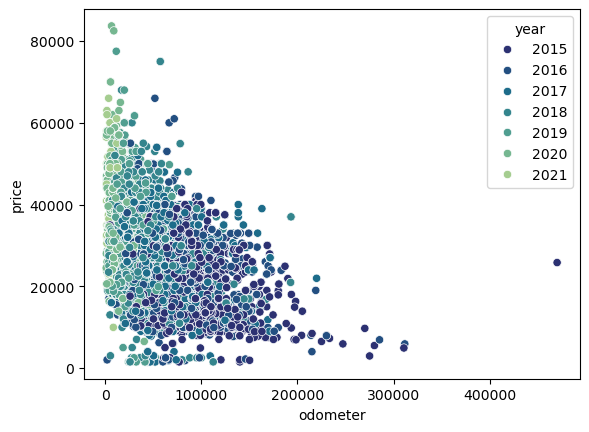

In [122]:
toyota_gas_hybrid = df.query('manufacturer == "toyota" and fuel in ["gas","hybrid"] and ' + \
                             '1e3 < price < 1e6 and 1e3 < odometer < 0.5e6 and ' + \
                             '2015 <= year <= 2021')
sns.scatterplot(data=toyota_gas_hybrid,x='odometer',y='price',hue='year',palette='crest_r')
legend_handles, legend_labels = g.get_legend_handles_labels()
g.legend(legend_handles, legend_labels, title = 'Year')
g.set_xlabel('Odometer reading (miles)')
g.set_ylabel('Price (USD)')
g.set_title('Toyota prices vs. odometer reading by the year')

Let's conclude with the boxplot

Text(0.5, 1.0, 'Toyota Tacoma prices by the year')

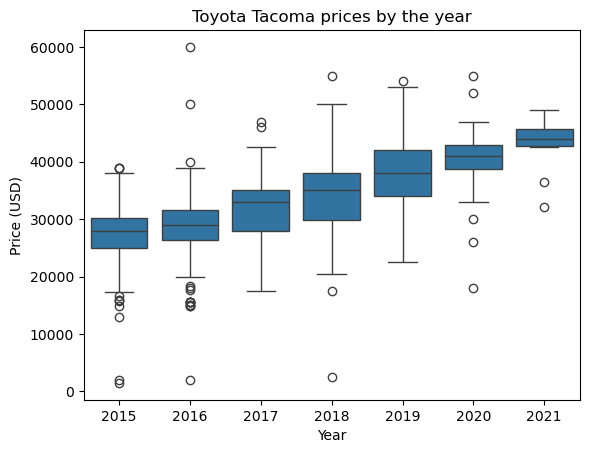

In [125]:
tacoma = df.query('manufacturer == "toyota" and model == "tacoma" and ' + \
                  '2015 <= year <= 2021 and ' + \
                  'price > 1e3')[['year','price']]
tacoma['year'] = tacoma['year'].astype(int)
g = sns.boxplot(data=tacoma,x='year',y='price')
g.set_xlabel('Year')
g.set_ylabel('Price (USD)')
g.set_title('Toyota Tacoma prices by the year')